# Diagnóstico do colapso e da recuperação INT8

Este notebook gera figuras independentes e tabelas reprodutíveis para analisar escalas de ativação, utilização de códigos INT8, agrupamento estrutural, pesos e recuperação de acurácia.

As figuras são salvas separadamente em PNG e PDF.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

In [2]:
CURRENT_DIR = Path.cwd().resolve()
EDGE_ROOT_CANDIDATES = [
    CURRENT_DIR,
    CURRENT_DIR / "butterflies_austria_edge_vision",
    *CURRENT_DIR.parents,
]
EDGE_ROOT = next(
    (
        candidate
        for candidate in EDGE_ROOT_CANDIDATES
        if (candidate / "pytorch_mobilevit_xxs").is_dir()
        and (candidate / "artigo_experimentos").is_dir()
    ),
    None,
)
if EDGE_ROOT is None:
    raise FileNotFoundError("Could not locate butterflies_austria_edge_vision")

ARTICLE_DIR = EDGE_ROOT / "artigo_experimentos"
EXPERIMENT_DIR = ARTICLE_DIR / "artigo_experimentos_MobileVIT_v2_esp_verify"
RESULTS_DIR = EXPERIMENT_DIR / "test1_results"
CHECKPOINT_PATH = EXPERIMENT_DIR / "best_mobilevit_xx_small_v0.pt"
BLOCK7_RESULTS_DIR = (
    ARTICLE_DIR
    / "artigo_experimentos_MobileVIT_v3_block7"
    / "results"
    / "g8_4_4_block7_g8"
)
OUTPUT_DIR = ARTICLE_DIR / "gerar_plots"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in (FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

required_paths = [
    RESULTS_DIR / "channel_statistics.csv",
    RESULTS_DIR / "group_statistics.csv",
    RESULTS_DIR / "group_configuration.json",
    RESULTS_DIR / "results.csv",
    CHECKPOINT_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Missing required files: {missing_paths}")

print(f"Figures: {FIGURES_DIR}")
print(f"Tables: {TABLES_DIR}")

Figures: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/gerar_plots/figures
Tables: /home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/artigo_experimentos/gerar_plots/tables


## 1. Escalas de ativação

A razão entre a maior e a menor escala detecta valores extremos, mas é sensível a poucos canais. A utilização de códigos INT8 mede a prevalência da compressão em cada bloco. As duas evidências devem ser apresentadas separadamente.

In [3]:
channel_statistics = pd.read_csv(RESULTS_DIR / "channel_statistics.csv")
group_statistics = pd.read_csv(RESULTS_DIR / "group_statistics.csv")
results = pd.read_csv(RESULTS_DIR / "results.csv")

with (RESULTS_DIR / "group_configuration.json").open() as file:
    group_configuration = {
        int(block): groups
        for block, groups in json.load(file).items()
    }

expected_columns = {
    "block",
    "block_name",
    "channel",
    "minimum",
    "maximum",
    "channel_scale",
    "tensor_scale",
    "approximate_int8_codes",
}
missing_columns = expected_columns.difference(channel_statistics.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

selected_blocks = sorted(group_configuration)
channel_statistics["selected_for_grouping"] = channel_statistics["block"].isin(selected_blocks)

block_summary = (
    channel_statistics.groupby(["block", "block_name"], as_index=False)
    .agg(
        channel_count=("channel", "count"),
        minimum_channel_scale=("channel_scale", "min"),
        maximum_channel_scale=("channel_scale", "max"),
        median_channel_scale=("channel_scale", "median"),
        minimum_approximate_codes=("approximate_int8_codes", "min"),
        median_approximate_codes=("approximate_int8_codes", "median"),
        channels_with_at_most_16_codes=("approximate_int8_codes", lambda values: int((values <= 16).sum())),
        channels_with_at_most_32_codes=("approximate_int8_codes", lambda values: int((values <= 32).sum())),
    )
)
block_summary["scale_ratio"] = (
    block_summary["maximum_channel_scale"]
    / block_summary["minimum_channel_scale"]
)
block_summary["fraction_at_most_16_codes"] = (
    block_summary["channels_with_at_most_16_codes"] / block_summary["channel_count"]
)
block_summary["fraction_at_most_32_codes"] = (
    block_summary["channels_with_at_most_32_codes"] / block_summary["channel_count"]
)
block_summary["selected_for_grouping"] = block_summary["block"].isin(selected_blocks)
block_summary.to_csv(TABLES_DIR / "block_activation_summary.csv", index=False)

display(
    block_summary[
        [
            "block",
            "channel_count",
            "scale_ratio",
            "minimum_approximate_codes",
            "median_approximate_codes",
            "channels_with_at_most_16_codes",
            "selected_for_grouping",
        ]
    ].round(2)
)

,block,channel_count,scale_ratio,minimum_approximate_codes,median_approximate_codes,channels_with_at_most_16_codes,selected_for_grouping
0,1,32,327.61,1,8.0,19,True
1,2,32,874.36,1,10.0,18,True
2,3,48,156.28,2,6.0,41,False
3,4,48,94.35,3,37.5,13,False
4,5,48,318.00,1,8.5,32,True
5,6,96,107.49,3,49.5,19,False
6,7,128,487.58,1,47.0,27,False


In [4]:
def save_figure(figure, name):
    png_path = FIGURES_DIR / f"{name}.png"
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print(f"Saved: {png_path.name}, {pdf_path.name}")

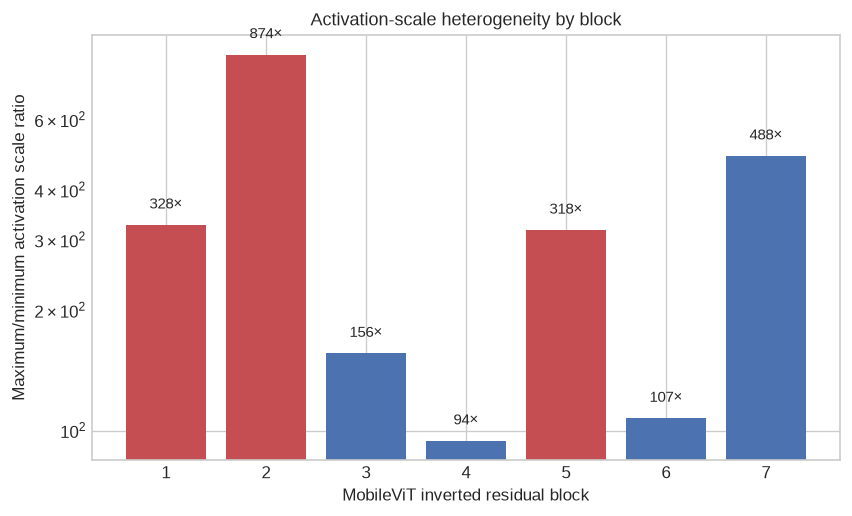

Saved: activation_scale_ratio_by_block.png, activation_scale_ratio_by_block.pdf


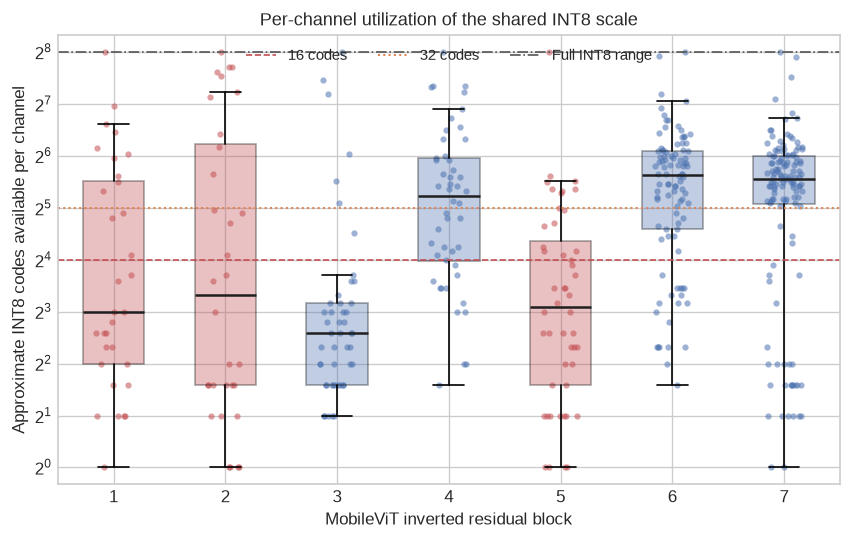

Saved: int8_code_utilization_by_block.png, int8_code_utilization_by_block.pdf


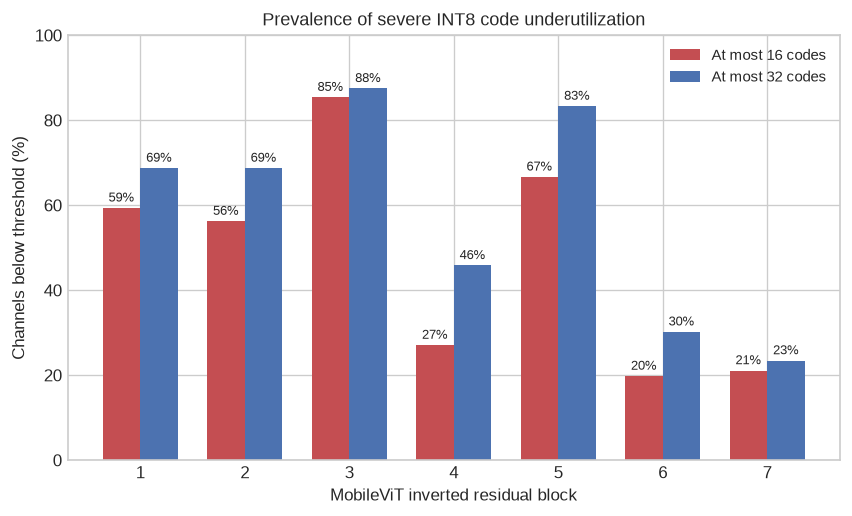

Saved: int8_starved_channel_fraction_by_block.png, int8_starved_channel_fraction_by_block.pdf


In [5]:
blocks = block_summary["block"].astype(int).to_numpy()
ratios = block_summary["scale_ratio"].to_numpy()
colors = [
    "#C44E52" if selected else "#4C72B0"
    for selected in block_summary["selected_for_grouping"]
]

figure, axis = plt.subplots(figsize=(7.2, 4.4))
bars = axis.bar(blocks, ratios, color=colors)
axis.set_yscale("log")
axis.set_xticks(blocks)
axis.set_xlabel("MobileViT inverted residual block")
axis.set_ylabel("Maximum/minimum activation scale ratio")
axis.set_title("Activation-scale heterogeneity by block")
for bar, value in zip(bars, ratios):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.08,
        f"{value:.0f}×",
        ha="center",
        va="bottom",
        fontsize=9,
    )
figure.tight_layout()
save_figure(figure, "activation_scale_ratio_by_block")

code_values = [
    channel_statistics.loc[
        channel_statistics["block"] == block,
        "approximate_int8_codes",
    ].to_numpy()
    for block in blocks
]
figure, axis = plt.subplots(figsize=(7.2, 4.6))
boxplot = axis.boxplot(
    code_values,
    positions=blocks,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#1F1F1F", "linewidth": 1.5},
)
for patch, color in zip(boxplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

random_generator = np.random.default_rng(7)
for block, values, color in zip(blocks, code_values, colors):
    jitter = random_generator.uniform(-0.16, 0.16, size=len(values))
    axis.scatter(
        np.full(len(values), block) + jitter,
        values,
        s=14,
        color=color,
        alpha=0.55,
        linewidth=0,
    )
axis.axhline(16, color="#C44E52", linestyle="--", linewidth=1, label="16 codes")
axis.axhline(32, color="#DD8452", linestyle=":", linewidth=1.2, label="32 codes")
axis.axhline(256, color="#555555", linestyle="-.", linewidth=1, label="Full INT8 range")
axis.set_yscale("log", base=2)
axis.set_ylim(0.8, 320)
axis.set_xticks(blocks)
axis.set_xlabel("MobileViT inverted residual block")
axis.set_ylabel("Approximate INT8 codes available per channel")
axis.set_title("Per-channel utilization of the shared INT8 scale")
axis.legend(frameon=False, ncol=3, loc="upper center")
figure.tight_layout()
save_figure(figure, "int8_code_utilization_by_block")

x = np.arange(len(blocks))
width = 0.36
fraction_16 = block_summary["fraction_at_most_16_codes"].to_numpy() * 100
fraction_32 = block_summary["fraction_at_most_32_codes"].to_numpy() * 100
figure, axis = plt.subplots(figsize=(7.2, 4.4))
bars_16 = axis.bar(x - width / 2, fraction_16, width, label="At most 16 codes", color="#C44E52")
bars_32 = axis.bar(x + width / 2, fraction_32, width, label="At most 32 codes", color="#4C72B0")
axis.set_xticks(x, blocks)
axis.set_ylim(0, 100)
axis.set_xlabel("MobileViT inverted residual block")
axis.set_ylabel("Channels below threshold (%)")
axis.set_title("Prevalence of severe INT8 code underutilization")
axis.legend(frameon=False)
for bars in (bars_16, bars_32):
    for bar in bars:
        value = bar.get_height()
        axis.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.0f}%", ha="center", fontsize=8)
figure.tight_layout()
save_figure(figure, "int8_starved_channel_fraction_by_block")

## 2. Efeito do agrupamento estrutural g8_4_4

A razão máxima/mínima caracteriza heterogeneidade extrema, não a prevalência do problema. O bloco 7 tem razão elevada, mas utilização mediana maior que a dos blocos 1, 2, 3 e 5. O bloco 3 tem razão menor, porém uma fração maior de canais severamente comprimidos. Assim, g8_4_4 deve ser descrito como intervenção estrutural avaliada empiricamente, não como resultado automático de ordenar blocos pela razão extrema.

In [6]:
group_lookup = {
    (block, int(channel)): group_index + 1
    for block, groups in group_configuration.items()
    for group_index, channels in enumerate(groups)
    for channel in channels
}

selected_channel_statistics = channel_statistics[
    channel_statistics["block"].isin(selected_blocks)
].copy()
selected_channel_statistics["group"] = [
    group_lookup[(int(block), int(channel))]
    for block, channel in zip(
        selected_channel_statistics["block"],
        selected_channel_statistics["channel"],
    )
]

worst_group_ratio = (
    group_statistics.groupby("block", as_index=False)["scale_ratio"]
    .max()
    .rename(columns={"scale_ratio": "maximum_within_group_ratio"})
)
grouping_summary = (
    block_summary[block_summary["block"].isin(selected_blocks)][
        ["block", "scale_ratio"]
    ]
    .rename(columns={"scale_ratio": "original_tensor_ratio"})
    .merge(worst_group_ratio, on="block", how="left")
)
grouping_summary["ratio_reduction"] = (
    grouping_summary["original_tensor_ratio"]
    / grouping_summary["maximum_within_group_ratio"]
)
grouping_summary.to_csv(TABLES_DIR / "grouping_scale_summary.csv", index=False)

display(grouping_summary.round(2))

,block,original_tensor_ratio,maximum_within_group_ratio,ratio_reduction
0,1,327.61,2.92,112.15
1,2,874.36,6.97,125.52
2,5,318.00,10.31,30.86


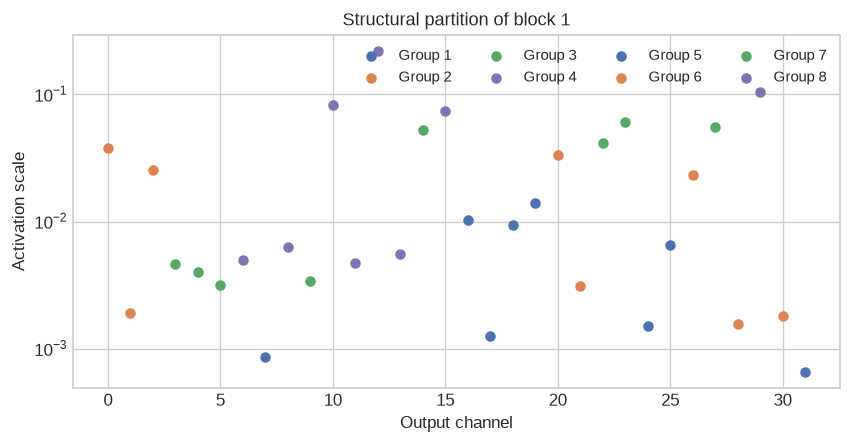

Saved: structural_partition_block_1.png, structural_partition_block_1.pdf


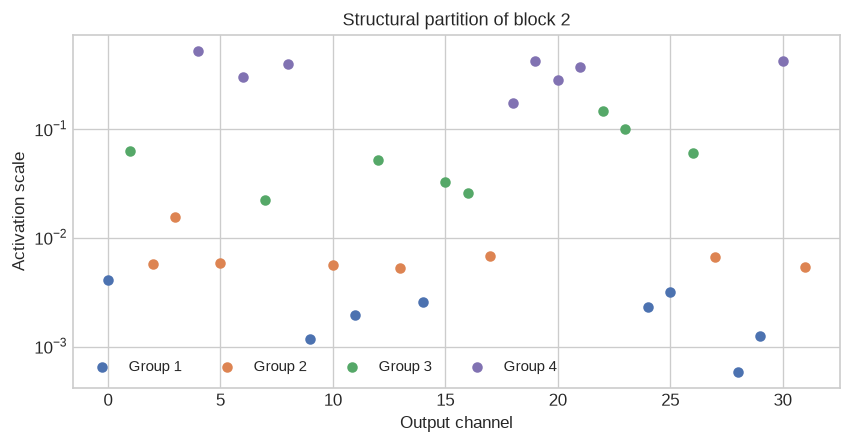

Saved: structural_partition_block_2.png, structural_partition_block_2.pdf


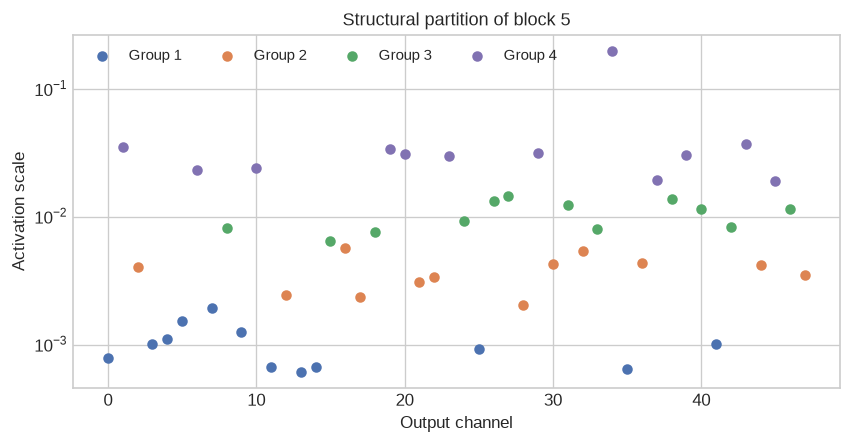

Saved: structural_partition_block_5.png, structural_partition_block_5.pdf


In [7]:
group_colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B2"]

for block in selected_blocks:
    block_data = selected_channel_statistics[
        selected_channel_statistics["block"] == block
    ].sort_values("channel")
    figure, axis = plt.subplots(figsize=(7.2, 3.8))
    for group, group_data in block_data.groupby("group"):
        axis.scatter(
            group_data["channel"],
            group_data["channel_scale"],
            s=28,
            color=group_colors[(int(group) - 1) % len(group_colors)],
            label=f"Group {int(group)}",
        )
    axis.set_yscale("log")
    axis.set_xlabel("Output channel")
    axis.set_ylabel("Activation scale")
    axis.set_title(f"Structural partition of block {block}")
    axis.legend(frameon=False, ncol=4)
    figure.tight_layout()
    save_figure(figure, f"structural_partition_block_{block}")

## 3. Distribuição dos pesos e relação com as ativações

A distribuição dos pesos e a associação peso–ativação são análises distintas. A primeira descreve as distribuições. A segunda testa associação estatística e não estabelece causalidade.

In [8]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

def find_tensor_by_suffix(suffix):
    matches = [
        (name, tensor)
        for name, tensor in state_dict.items()
        if name.endswith(suffix)
    ]
    if len(matches) != 1:
        raise KeyError(f"Expected one tensor ending with {suffix}, found {len(matches)}")
    return matches[0]

weight_records = []
weight_channel_records = []

for row in block_summary.itertuples(index=False):
    suffix = f"{row.block_name}.expand_1x1.convolution.weight"
    parameter_name, tensor = find_tensor_by_suffix(suffix)
    weights = tensor.detach().float().cpu().numpy()
    flattened_by_channel = weights.reshape(weights.shape[0], -1)

    for value in weights.reshape(-1):
        weight_records.append({
            "block": int(row.block),
            "weight": float(value),
        })

    activation_rows = (
        channel_statistics[channel_statistics["block"] == row.block]
        .sort_values("channel")
        .reset_index(drop=True)
    )
    if len(activation_rows) != weights.shape[0]:
        raise ValueError(
            f"Channel mismatch in block {row.block}: "
            f"{len(activation_rows)} activation channels and {weights.shape[0]} filters"
        )

    for channel, channel_weights in enumerate(flattened_by_channel):
        weight_channel_records.append({
            "block": int(row.block),
            "channel": channel,
            "weight_abs_max": float(np.max(np.abs(channel_weights))),
            "weight_mean_abs": float(np.mean(np.abs(channel_weights))),
            "weight_std": float(np.std(channel_weights)),
            "activation_scale": float(
                activation_rows.loc[channel, "channel_scale"]
            ),
        })

weight_distribution = pd.DataFrame(weight_records)
weight_channel_statistics = pd.DataFrame(weight_channel_records)
weight_channel_statistics.to_csv(
    TABLES_DIR / "expansion_weight_channel_statistics.csv",
    index=False,
)

display(
    weight_channel_statistics.groupby("block", as_index=False).agg(
        minimum_weight_abs_max=("weight_abs_max", "min"),
        maximum_weight_abs_max=("weight_abs_max", "max"),
        median_weight_abs_max=("weight_abs_max", "median"),
        median_weight_std=("weight_std", "median"),
    ).round(5)
)

,block,minimum_weight_abs_max,maximum_weight_abs_max,median_weight_abs_max,median_weight_std
0,1,0.35808,2.11202,0.78810,0.25473
1,2,0.34994,0.78109,0.49900,0.20005
2,3,0.36822,1.57167,0.53743,0.21019
3,4,0.33739,0.90563,0.46083,0.19594
4,5,0.37962,1.52346,0.50643,0.19641
5,6,0.38002,1.11891,0.59147,0.19537
6,7,0.37824,1.31964,0.54271,0.19697


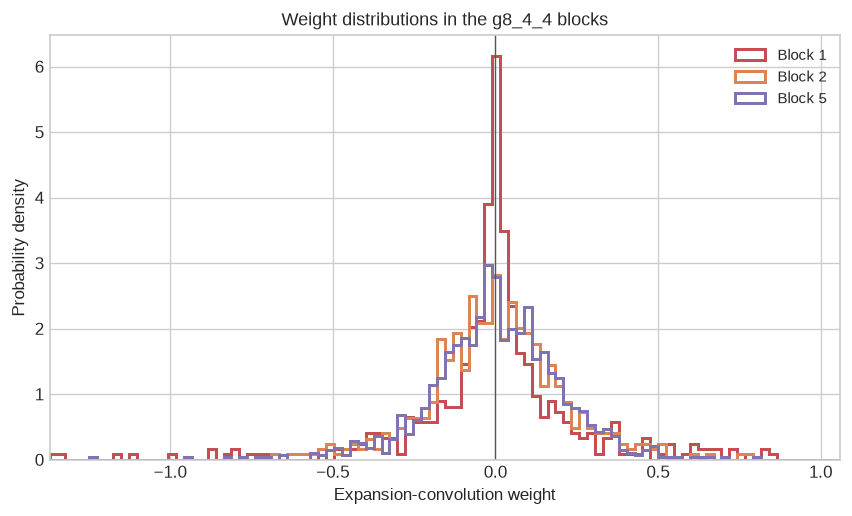

Saved: weight_distribution_selected_blocks.png, weight_distribution_selected_blocks.pdf


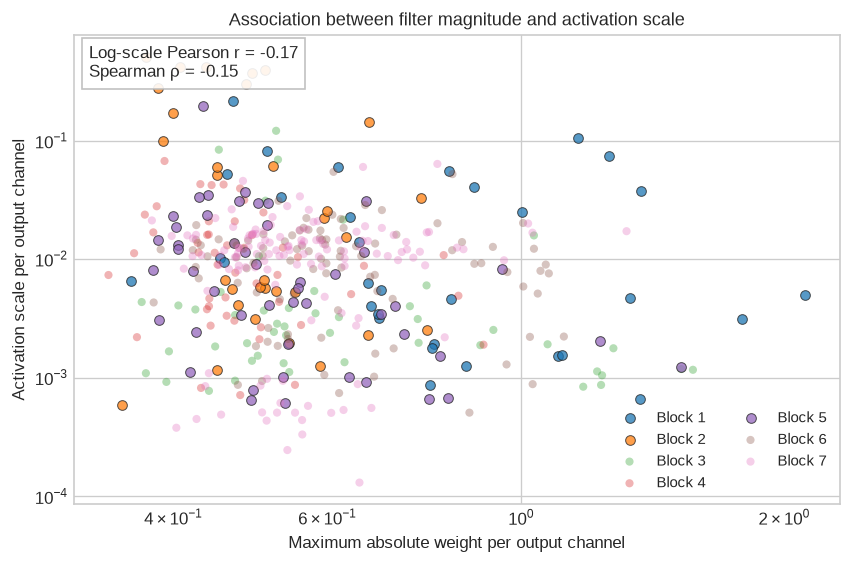

Saved: weight_activation_relationship.png, weight_activation_relationship.pdf


,block,channel_count,pearson_log,spearman
0,1,32,-0.270,-0.310
1,2,32,-0.282,-0.319
2,3,48,-0.236,-0.162
3,4,48,-0.259,-0.296
4,5,48,-0.431,-0.449
5,6,96,-0.121,-0.087
6,7,128,0.112,0.076


In [9]:
selected_weight_distribution = weight_distribution[
    weight_distribution["block"].isin(selected_blocks)
].copy()
finite_weights = selected_weight_distribution.loc[
    np.isfinite(selected_weight_distribution["weight"]),
    "weight",
].to_numpy()
if finite_weights.size == 0:
    raise RuntimeError("No finite weights available")

lower_limit, upper_limit = np.quantile(finite_weights, [0.001, 0.999])
bins = np.linspace(lower_limit, upper_limit, 101)
figure, axis = plt.subplots(figsize=(7.2, 4.4))
for block, color in zip(selected_blocks, ["#C44E52", "#DD8452", "#8172B2"]):
    values = selected_weight_distribution.loc[
        selected_weight_distribution["block"] == block,
        "weight",
    ].to_numpy()
    axis.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        color=color,
        label=f"Block {block}",
    )
axis.axvline(0, color="#555555", linewidth=0.8)
axis.set_xlim(lower_limit, upper_limit)
axis.set_xlabel("Expansion-convolution weight")
axis.set_ylabel("Probability density")
axis.set_title("Weight distributions in the g8_4_4 blocks")
axis.legend(frameon=False)
figure.tight_layout()
save_figure(figure, "weight_distribution_selected_blocks")

valid_relation = weight_channel_statistics[
    (weight_channel_statistics["weight_abs_max"] > 0)
    & (weight_channel_statistics["activation_scale"] > 0)
].copy()
valid_relation["log_weight_abs_max"] = np.log10(valid_relation["weight_abs_max"])
valid_relation["log_activation_scale"] = np.log10(valid_relation["activation_scale"])
pearson_log = float(valid_relation[["log_weight_abs_max", "log_activation_scale"]].corr(method="pearson").iloc[0, 1])
spearman = float(valid_relation[["weight_abs_max", "activation_scale"]].corr(method="spearman").iloc[0, 1])

correlation_rows = []
for block, frame in valid_relation.groupby("block"):
    correlation_rows.append({
        "block": int(block),
        "channel_count": len(frame),
        "pearson_log": frame[["log_weight_abs_max", "log_activation_scale"]].corr(method="pearson").iloc[0, 1],
        "spearman": frame[["weight_abs_max", "activation_scale"]].corr(method="spearman").iloc[0, 1],
    })
per_block_correlations = pd.DataFrame(correlation_rows)
per_block_correlations.to_csv(TABLES_DIR / "weight_activation_correlations_by_block.csv", index=False)

figure, axis = plt.subplots(figsize=(7.2, 4.8))
palette = plt.get_cmap("tab10")
for block in sorted(valid_relation["block"].unique()):
    block_data = valid_relation[valid_relation["block"] == block]
    selected = block in selected_blocks
    axis.scatter(
        block_data["weight_abs_max"],
        block_data["activation_scale"],
        s=34 if selected else 24,
        alpha=0.75 if selected else 0.35,
        color=palette((int(block) - 1) % 10),
        edgecolor="#1F1F1F" if selected else "none",
        linewidth=0.6 if selected else 0,
        label=f"Block {int(block)}",
    )
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("Maximum absolute weight per output channel")
axis.set_ylabel("Activation scale per output channel")
axis.set_title("Association between filter magnitude and activation scale")
axis.text(
    0.02,
    0.98,
    f"Log-scale Pearson r = {pearson_log:.2f}\nSpearman ρ = {spearman:.2f}",
    transform=axis.transAxes,
    ha="left",
    va="top",
    bbox={"facecolor": "white", "edgecolor": "#BBBBBB", "alpha": 0.9},
)
axis.legend(frameon=False, ncol=2, loc="lower right")
figure.tight_layout()
save_figure(figure, "weight_activation_relationship")
display(per_block_correlations.round(3))

## 4. Recuperação INT8

A figura mostra somente as etapas necessárias para quantificar o colapso e a recuperação: FP32 original, INT8 original e INT8 com g8_4_4. O FP32 agrupado permanece no resumo como controle de equivalência.

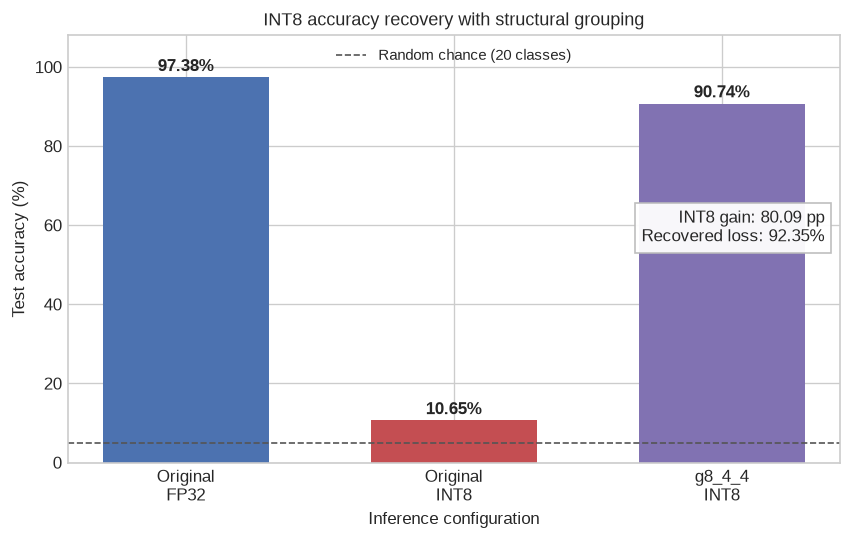

Saved: int8_accuracy_recovery.png, int8_accuracy_recovery.pdf
{
  "original_fp32_test_accuracy": 0.9737654320987654,
  "original_int8_test_accuracy": 0.1064814814814814,
  "grouped_fp32_test_accuracy": 0.9737654320987654,
  "grouped_int8_test_accuracy": 0.9074074074074074,
  "int8_collapse_percentage_points": 86.7283950617284,
  "grouping_gain_percentage_points": 80.09259259259261,
  "fraction_of_lost_accuracy_recovered": 0.9234875444839858,
  "weight_activation_log_pearson": -0.1676633093868006,
  "weight_activation_spearman": -0.14559641035075466
}


In [10]:
test_results = results[results["split"] == "test"].copy()
accuracy_by_model = test_results.set_index("model")["accuracy"]
required_models = {"original_fp32", "original_int8", "grouped_fp32", "grouped_int8"}
missing_models = required_models.difference(accuracy_by_model.index)
if missing_models:
    raise ValueError(f"Missing test results: {sorted(missing_models)}")

collapse_drop = float(accuracy_by_model["original_fp32"] - accuracy_by_model["original_int8"])
grouping_gain = float(accuracy_by_model["grouped_int8"] - accuracy_by_model["original_int8"])
recovered_fraction = grouping_gain / collapse_drop
plot_models = ["original_fp32", "original_int8", "grouped_int8"]
plot_labels = ["Original\nFP32", "Original\nINT8", "g8_4_4\nINT8"]
plot_accuracies = [float(accuracy_by_model[model]) * 100 for model in plot_models]

figure, axis = plt.subplots(figsize=(7.2, 4.6))
bars = axis.bar(plot_labels, plot_accuracies, color=["#4C72B0", "#C44E52", "#8172B2"], width=0.62)
axis.axhline(5, color="#555555", linestyle="--", linewidth=1, label="Random chance (20 classes)")
axis.set_ylim(0, 108)
axis.set_ylabel("Test accuracy (%)")
axis.set_xlabel("Inference configuration")
axis.set_title("INT8 accuracy recovery with structural grouping")
axis.legend(frameon=False, loc="upper center")
for bar, accuracy in zip(bars, plot_accuracies):
    axis.text(bar.get_x() + bar.get_width() / 2, accuracy + 1.6, f"{accuracy:.2f}%", ha="center", fontweight="bold")
axis.text(
    0.98,
    0.55,
    f"INT8 gain: {grouping_gain * 100:.2f} pp\nRecovered loss: {recovered_fraction * 100:.2f}%",
    transform=axis.transAxes,
    ha="right",
    va="center",
    bbox={"facecolor": "white", "edgecolor": "#BBBBBB", "alpha": 0.95},
)
figure.tight_layout()
save_figure(figure, "int8_accuracy_recovery")

diagnostic_summary = {
    "original_fp32_test_accuracy": float(accuracy_by_model["original_fp32"]),
    "original_int8_test_accuracy": float(accuracy_by_model["original_int8"]),
    "grouped_fp32_test_accuracy": float(accuracy_by_model["grouped_fp32"]),
    "grouped_int8_test_accuracy": float(accuracy_by_model["grouped_int8"]),
    "int8_collapse_percentage_points": collapse_drop * 100,
    "grouping_gain_percentage_points": grouping_gain * 100,
    "fraction_of_lost_accuracy_recovered": recovered_fraction,
    "weight_activation_log_pearson": pearson_log,
    "weight_activation_spearman": spearman,
}
with (TABLES_DIR / "diagnostic_summary.json").open("w") as file:
    json.dump(diagnostic_summary, file, indent=2)
print(json.dumps(diagnostic_summary, indent=2))

## 5. Interpretação para o artigo

1. A quantização INT8 original sofre colapso de acurácia.
2. As ativações apresentam heterogeneidade entre canais.
3. A fração de canais com poucos códigos complementa a razão máxima/mínima e evita selecionar blocos apenas por valores extremos.
4. A distribuição dos pesos não mede diretamente a faixa dinâmica das ativações.
5. Correlação peso–ativação fraca indica que a magnitude dos filtros, isoladamente, não explica o problema.
6. O agrupamento g8_4_4 reduz a heterogeneidade dentro dos grupos e recupera grande parte da acurácia INT8 perdida.
7. A inclusão do bloco 7 deve ser sustentada por ablação de validação, não somente por sua razão extrema.

## 6. Ablação do bloco 7

O gráfico mede o efeito incremental de adicionar o bloco 7 ao g8_4_4. A validação orienta a configuração; o teste deve ser usado somente na avaliação final.

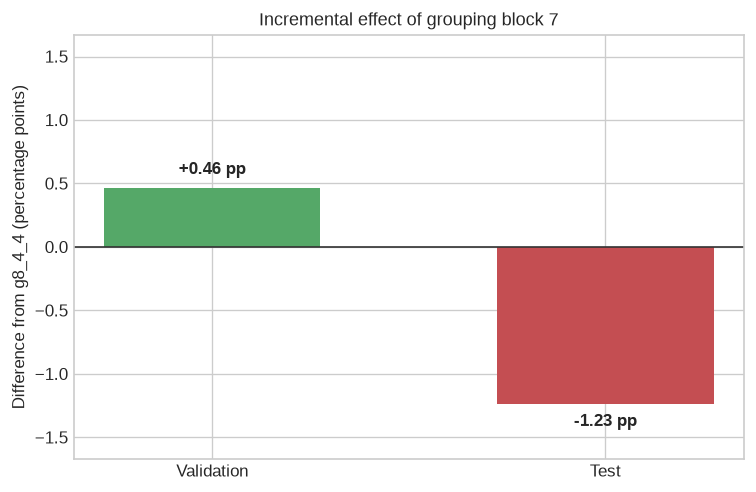

Saved: block7_incremental_accuracy_delta.png, block7_incremental_accuracy_delta.pdf


,split,g8_4_4_accuracy,g8_4_4_block7_accuracy,delta_percentage_points
0,validation,0.8966,0.9012,0.4630
1,test,0.9074,0.8951,-1.2346


In [11]:
block7_results_path = BLOCK7_RESULTS_DIR / "results.csv"
if block7_results_path.exists():
    block7_results = pd.read_csv(block7_results_path)
    baseline_grouped = results[results["model"] == "grouped_int8"].set_index("split")["accuracy"]
    block7_grouped = block7_results[block7_results["model"] == "grouped_int8"].set_index("split")["accuracy"]
    split_order = ["validation", "test"]
    delta_percentage_points = np.array([
        (float(block7_grouped[split]) - float(baseline_grouped[split])) * 100
        for split in split_order
    ])
    block7_ablation = pd.DataFrame({
        "split": split_order,
        "g8_4_4_accuracy": [float(baseline_grouped[split]) for split in split_order],
        "g8_4_4_block7_accuracy": [float(block7_grouped[split]) for split in split_order],
        "delta_percentage_points": delta_percentage_points,
    })
    block7_ablation.to_csv(TABLES_DIR / "block7_ablation.csv", index=False)
    figure, axis = plt.subplots(figsize=(6.4, 4.2))
    bars = axis.bar(
        ["Validation", "Test"],
        delta_percentage_points,
        color=["#55A868" if value >= 0 else "#C44E52" for value in delta_percentage_points],
        width=0.55,
    )
    axis.axhline(0, color="#333333", linewidth=1)
    limit = max(1.5, float(np.max(np.abs(delta_percentage_points))) * 1.35)
    axis.set_ylim(-limit, limit)
    axis.set_ylabel("Difference from g8_4_4 (percentage points)")
    axis.set_title("Incremental effect of grouping block 7")
    for bar, value in zip(bars, delta_percentage_points):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + (0.08 if value >= 0 else -0.08),
            f"{value:+.2f} pp",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontweight="bold",
        )
    figure.tight_layout()
    save_figure(figure, "block7_incremental_accuracy_delta")
    display(block7_ablation.round(4))
else:
    print(f"Block 7 results not found: {block7_results_path}")

## 7. Comparação entre as configurações estruturais

Esta seção utiliza os resultados da avaliação comparativa mais recente para confrontar o modelo original, `g8_4_4` e `g8_4_4 + b3_g4`. A comparação entre todas as configurações é feita na validação. O teste é apresentado separadamente apenas para a configuração selecionada.

In [12]:
from ai_edge_litert.interpreter import Interpreter
from matplotlib.patches import Patch

V4_RESULTS_DIR = ARTICLE_DIR / "artigo_experimentos_MobileVIT_v4" / "results"
V4_SHARED_DIR = V4_RESULTS_DIR / "shared"
G844_DIR = V4_RESULTS_DIR / "variants" / "g8_4_4"
SELECTED_DIR = V4_RESULTS_DIR / "variants" / "g8_4_4_b3_g4"
MODELS_DIR = OUTPUT_DIR / "models"
G844_MODEL_PATH = MODELS_DIR / "mobilevit_g8_4_4_int8.tflite"
SELECTED_MODEL_PATH = MODELS_DIR / "mobilevit_g8_4_4_b3_g4_int8.tflite"

v4_required_paths = [
    V4_SHARED_DIR / "channel_statistics.csv",
    V4_SHARED_DIR / "original_validation_metrics.json",
    G844_DIR / "group_configuration.json",
    G844_DIR / "validation_metrics.json",
    SELECTED_DIR / "group_configuration.json",
    SELECTED_DIR / "validation_metrics.json",
    V4_RESULTS_DIR / "selected_test_results.csv",
    G844_MODEL_PATH,
    SELECTED_MODEL_PATH,
]
v4_missing_paths = [path for path in v4_required_paths if not path.is_file()]
if v4_missing_paths:
    raise FileNotFoundError(f"Missing required files: {v4_missing_paths}")

def load_json(path):
    with path.open() as file:
        return json.load(file)

def load_group_configuration(path):
    return {
        int(block): groups
        for block, groups in load_json(path).items()
    }

channel_statistics_v4 = pd.read_csv(V4_SHARED_DIR / "channel_statistics.csv")
g844_configuration = load_group_configuration(G844_DIR / "group_configuration.json")
selected_configuration = load_group_configuration(SELECTED_DIR / "group_configuration.json")
original_validation_metrics = load_json(V4_SHARED_DIR / "original_validation_metrics.json")
g844_validation_metrics = load_json(G844_DIR / "validation_metrics.json")
selected_validation_metrics = load_json(SELECTED_DIR / "validation_metrics.json")
selected_test_results = pd.read_csv(V4_RESULTS_DIR / "selected_test_results.csv")

def inspect_int8_model(name, path):
    interpreter = Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    tensor_details = interpreter.get_tensor_details()
    if input_detail["dtype"] != np.int8 or output_detail["dtype"] != np.int8:
        raise RuntimeError(f"{name} is not full INT8")
    quantized_tensor_count = sum(
        np.asarray(detail["quantization_parameters"]["scales"]).size > 0
        for detail in tensor_details
    )
    return {
        "model": name,
        "path": str(path),
        "size_mb": path.stat().st_size / 1024 / 1024,
        "input_dtype": np.dtype(input_detail["dtype"]).name,
        "output_dtype": np.dtype(output_detail["dtype"]).name,
        "tensor_count": len(tensor_details),
        "quantized_tensor_count": quantized_tensor_count,
    }

model_inspection = pd.DataFrame([
    inspect_int8_model("g8_4_4", G844_MODEL_PATH),
    inspect_int8_model("g8_4_4 + b3_g4", SELECTED_MODEL_PATH),
])
model_inspection.to_csv(TABLES_DIR / "compared_int8_models.csv", index=False)
display(model_inspection.round({"size_mb": 2}))

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,model,path,size_mb,input_dtype,output_dtype,tensor_count,quantized_tensor_count
0,g8_4_4,/home/jovyan/work/UFSC/butterflies_austria/but...,1.76,int8,int8,1145,1058
1,g8_4_4 + b3_g4,/home/jovyan/work/UFSC/butterflies_austria/but...,1.78,int8,int8,1187,1100


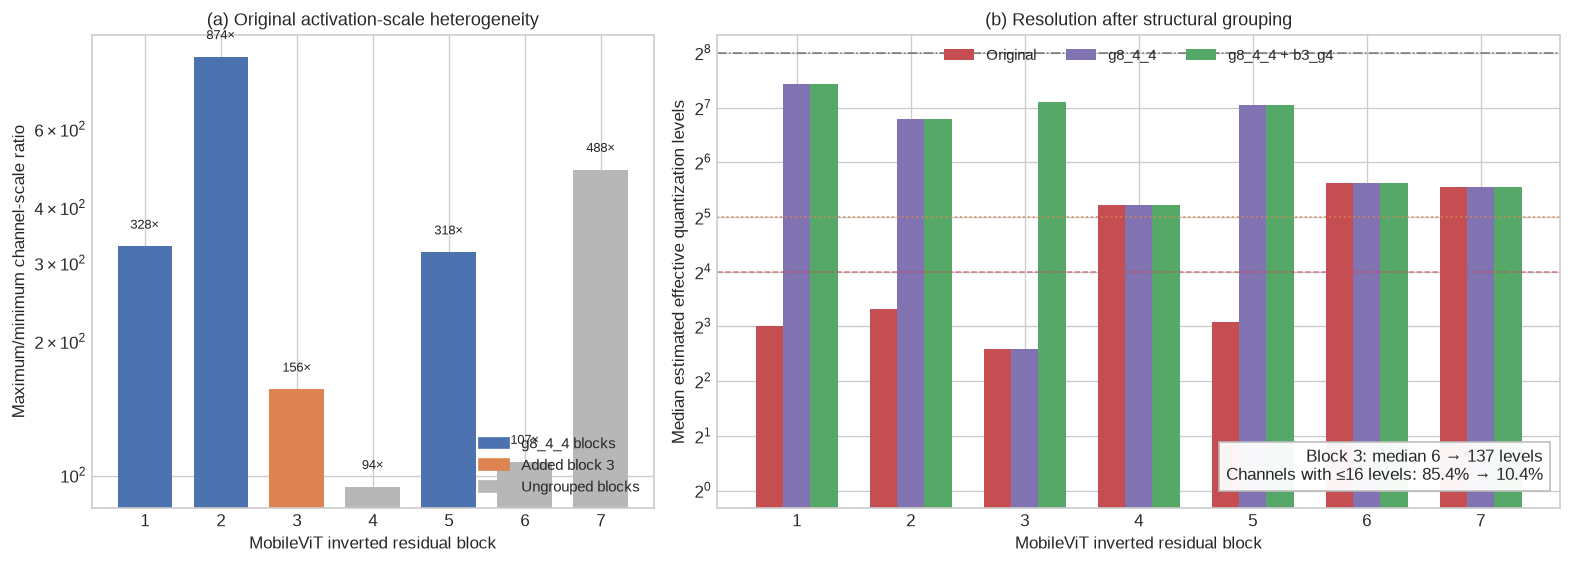

Saved: figure_1_activation_scale_diagnosis.png, figure_1_activation_scale_diagnosis.pdf


,configuration,block,minimum_effective_levels,median_effective_levels,fraction_at_most_16
0,Original,1,1,8.0,0.594
1,Original,2,1,10.0,0.562
2,Original,3,2,6.0,0.854
3,Original,4,3,37.5,0.271
4,Original,5,1,8.5,0.667
5,Original,6,3,49.5,0.198
6,Original,7,1,47.0,0.211
7,g8_4_4,1,86,172.0,0.000
8,g8_4_4,2,37,111.0,0.000
9,g8_4_4,3,2,6.0,0.854


In [13]:
def estimate_effective_levels(statistics, configuration, configuration_name):
    records = []
    for block, block_data in statistics.groupby("block"):
        indexed = block_data.set_index("channel")
        groups = configuration.get(int(block), [indexed.index.astype(int).tolist()])
        for group_index, channels in enumerate(groups):
            group_data = indexed.loc[channels]
            group_scale = max(
                float(group_data["maximum"].max() - group_data["minimum"].min()) / 255.0,
                np.finfo(np.float32).eps,
            )
            channel_ranges = group_data["maximum"] - group_data["minimum"]
            effective_levels = np.minimum(
                256,
                np.floor(channel_ranges / group_scale).astype(int) + 1,
            )
            for channel, levels in effective_levels.items():
                records.append({
                    "configuration": configuration_name,
                    "block": int(block),
                    "group": group_index + 1,
                    "channel": int(channel),
                    "estimated_effective_levels": int(levels),
                })
    return records

configuration_definitions = {
    "Original": {},
    "g8_4_4": g844_configuration,
    "g8_4_4 + b3_g4": selected_configuration,
}
effective_level_records = []
for configuration_name, configuration in configuration_definitions.items():
    effective_level_records.extend(
        estimate_effective_levels(
            channel_statistics_v4,
            configuration,
            configuration_name,
        )
    )

effective_levels = pd.DataFrame(effective_level_records)
effective_level_summary = (
    effective_levels.groupby(["configuration", "block"], as_index=False)
    .agg(
        minimum_effective_levels=("estimated_effective_levels", "min"),
        median_effective_levels=("estimated_effective_levels", "median"),
        fraction_at_most_16=("estimated_effective_levels", lambda values: float((values <= 16).mean())),
    )
)
effective_levels.to_csv(TABLES_DIR / "estimated_effective_levels_by_channel.csv", index=False)
effective_level_summary.to_csv(TABLES_DIR / "estimated_effective_levels_summary.csv", index=False)

activation_scale_summary = (
    channel_statistics_v4.groupby("block", as_index=False)
    .agg(
        minimum_channel_scale=("channel_scale", "min"),
        maximum_channel_scale=("channel_scale", "max"),
    )
)
activation_scale_summary["scale_ratio"] = (
    activation_scale_summary["maximum_channel_scale"]
    / activation_scale_summary["minimum_channel_scale"]
)

blocks = activation_scale_summary["block"].astype(int).to_numpy()
ratios = activation_scale_summary["scale_ratio"].to_numpy()
block_colors = [
    "#4C72B0" if block in {1, 2, 5} else "#DD8452" if block == 3 else "#B7B7B7"
    for block in blocks
]

figure, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), gridspec_kw={"width_ratios": [0.9, 1.35]})
bars = axes[0].bar(blocks, ratios, color=block_colors, width=0.72)
axes[0].set_yscale("log")
axes[0].set_xticks(blocks)
axes[0].set_xlabel("MobileViT inverted residual block")
axes[0].set_ylabel("Maximum/minimum channel-scale ratio")
axes[0].set_title("(a) Original activation-scale heterogeneity")
for bar, value in zip(bars, ratios):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.08,
        f"{value:.0f}×",
        ha="center",
        va="bottom",
        fontsize=8,
    )
axes[0].legend(
    handles=[
        Patch(color="#4C72B0", label="g8_4_4 blocks"),
        Patch(color="#DD8452", label="Added block 3"),
        Patch(color="#B7B7B7", label="Ungrouped blocks"),
    ],
    frameon=False,
    loc="lower right",
)

configuration_order = ["Original", "g8_4_4", "g8_4_4 + b3_g4"]
configuration_colors = ["#C44E52", "#8172B2", "#55A868"]
bar_width = 0.24
x_positions = np.arange(len(blocks))
for offset, configuration_name, color in zip((-bar_width, 0, bar_width), configuration_order, configuration_colors):
    configuration_values = (
        effective_level_summary[effective_level_summary["configuration"] == configuration_name]
        .set_index("block")
        .loc[blocks, "median_effective_levels"]
        .to_numpy()
    )
    axes[1].bar(
        x_positions + offset,
        configuration_values,
        width=bar_width,
        color=color,
        label=configuration_name,
    )
axes[1].axhline(16, color="#C44E52", linestyle="--", linewidth=0.9, alpha=0.7)
axes[1].axhline(32, color="#DD8452", linestyle=":", linewidth=1.1, alpha=0.8)
axes[1].axhline(256, color="#555555", linestyle="-.", linewidth=0.9, alpha=0.8)
axes[1].set_yscale("log", base=2)
axes[1].set_ylim(0.8, 320)
axes[1].set_xticks(x_positions, blocks)
axes[1].set_xlabel("MobileViT inverted residual block")
axes[1].set_ylabel("Median estimated effective quantization levels")
axes[1].set_title("(b) Resolution after structural grouping")
axes[1].legend(frameon=False, ncol=3, loc="upper center")
axes[1].text(
    0.98,
    0.05,
    "Block 3: median 6 → 137 levels\nChannels with ≤16 levels: 85.4% → 10.4%",
    transform=axes[1].transAxes,
    ha="right",
    va="bottom",
    bbox={"facecolor": "white", "edgecolor": "#BBBBBB", "alpha": 0.95},
)
figure.tight_layout()
save_figure(figure, "figure_1_activation_scale_diagnosis")
display(effective_level_summary.round(3))

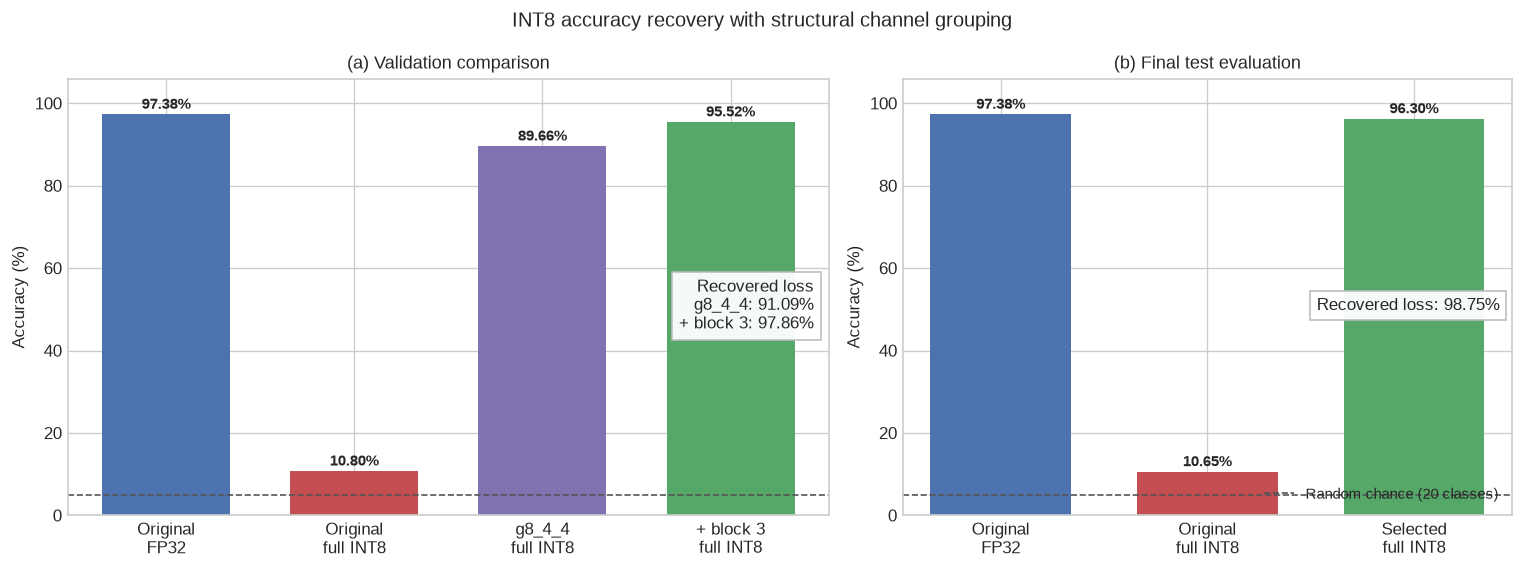

Saved: figure_4_int8_accuracy_recovery.png, figure_4_int8_accuracy_recovery.pdf


,split,configuration,accuracy,recovered_fraction
0,validation,Original FP32,0.9738,NaN
1,validation,Original full INT8,0.1080,0.0000
2,validation,g8_4_4 full INT8,0.8966,0.9109
3,validation,g8_4_4 + b3_g4 full INT8,0.9552,0.9786
4,test,Original FP32,0.9738,NaN
5,test,Original full INT8,0.1065,0.0000
6,test,g8_4_4 + b3_g4 full INT8,0.9630,0.9875


In [14]:
validation_fp32 = float(original_validation_metrics["fp32"]["accuracy"])
validation_original_int8 = float(original_validation_metrics["int8"]["accuracy"])
validation_g844_int8 = float(g844_validation_metrics["grouped_int8"]["accuracy"])
validation_selected_int8 = float(selected_validation_metrics["grouped_int8"]["accuracy"])
test_accuracy = selected_test_results.set_index("model")["accuracy"]
test_fp32 = float(test_accuracy["original_fp32"])
test_original_int8 = float(test_accuracy["original_int8"])
test_selected_int8 = float(test_accuracy["selected_int8"])

validation_g844_recovery = (validation_g844_int8 - validation_original_int8) / (validation_fp32 - validation_original_int8)
validation_selected_recovery = (validation_selected_int8 - validation_original_int8) / (validation_fp32 - validation_original_int8)
test_selected_recovery = (test_selected_int8 - test_original_int8) / (test_fp32 - test_original_int8)

accuracy_recovery = pd.DataFrame([
    {"split": "validation", "configuration": "Original FP32", "accuracy": validation_fp32, "recovered_fraction": np.nan},
    {"split": "validation", "configuration": "Original full INT8", "accuracy": validation_original_int8, "recovered_fraction": 0.0},
    {"split": "validation", "configuration": "g8_4_4 full INT8", "accuracy": validation_g844_int8, "recovered_fraction": validation_g844_recovery},
    {"split": "validation", "configuration": "g8_4_4 + b3_g4 full INT8", "accuracy": validation_selected_int8, "recovered_fraction": validation_selected_recovery},
    {"split": "test", "configuration": "Original FP32", "accuracy": test_fp32, "recovered_fraction": np.nan},
    {"split": "test", "configuration": "Original full INT8", "accuracy": test_original_int8, "recovered_fraction": 0.0},
    {"split": "test", "configuration": "g8_4_4 + b3_g4 full INT8", "accuracy": test_selected_int8, "recovered_fraction": test_selected_recovery},
])
accuracy_recovery.to_csv(TABLES_DIR / "accuracy_recovery_comparison.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
validation_labels = ["Original\nFP32", "Original\nfull INT8", "g8_4_4\nfull INT8", "+ block 3\nfull INT8"]
validation_values = np.array([validation_fp32, validation_original_int8, validation_g844_int8, validation_selected_int8]) * 100
validation_colors = ["#4C72B0", "#C44E52", "#8172B2", "#55A868"]
validation_bars = axes[0].bar(validation_labels, validation_values, color=validation_colors, width=0.68)
axes[0].axhline(5, color="#555555", linestyle="--", linewidth=1)
axes[0].set_ylim(0, 106)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("(a) Validation comparison")
for bar, value in zip(validation_bars, validation_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 1.3, f"{value:.2f}%", ha="center", fontweight="bold", fontsize=9)
axes[0].text(
    0.98,
    0.48,
    f"Recovered loss\ng8_4_4: {validation_g844_recovery * 100:.2f}%\n+ block 3: {validation_selected_recovery * 100:.2f}%",
    transform=axes[0].transAxes,
    ha="right",
    va="center",
    bbox={"facecolor": "white", "edgecolor": "#BBBBBB", "alpha": 0.95},
)

test_labels = ["Original\nFP32", "Original\nfull INT8", "Selected\nfull INT8"]
test_values = np.array([test_fp32, test_original_int8, test_selected_int8]) * 100
test_colors = ["#4C72B0", "#C44E52", "#55A868"]
test_bars = axes[1].bar(test_labels, test_values, color=test_colors, width=0.68)
axes[1].axhline(5, color="#555555", linestyle="--", linewidth=1, label="Random chance (20 classes)")
axes[1].set_ylim(0, 106)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("(b) Final test evaluation")
axes[1].legend(frameon=False, loc="lower right")
for bar, value in zip(test_bars, test_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 1.3, f"{value:.2f}%", ha="center", fontweight="bold", fontsize=9)
axes[1].text(
    0.98,
    0.48,
    f"Recovered loss: {test_selected_recovery * 100:.2f}%",
    transform=axes[1].transAxes,
    ha="right",
    va="center",
    bbox={"facecolor": "white", "edgecolor": "#BBBBBB", "alpha": 0.95},
)
figure.suptitle("INT8 accuracy recovery with structural channel grouping", fontsize=12)
figure.tight_layout()
save_figure(figure, "figure_4_int8_accuracy_recovery")
display(accuracy_recovery.round(4))